#### Importing important libraries

In [20]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

#### Reading the cvs file

In [21]:
df = pd.read_csv('Ice_cream selling data.csv')

In [22]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


#### Finding the correlation between features

In [23]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


#### visualizing the relation bewteen features

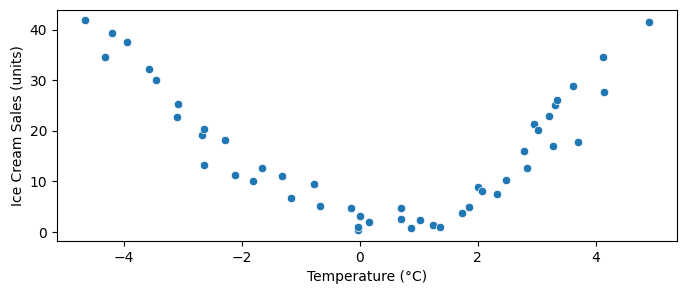

In [24]:
plt.figure(figsize=(8, 3))
sns.scatterplot(df, x="Temperature (°C)", y= "Ice Cream Sales (units)")
plt.show()

#### spliting the features and target column

In [25]:
x = df.drop(columns='Ice Cream Sales (units)') # feature column
y = df['Ice Cream Sales (units)']  # target column

#### splitting the data into train test for training the model

In [26]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

#### Creating the object for the model

In [27]:
model = LinearRegression()

#### Model training

In [28]:
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
ytrain_predicted = model.predict(xtrain)
train_score = r2_score(ytrain, ytrain_predicted)
train_score

0.06579063818532349

In [30]:
ytest_predicted = model.predict(xtest)
train_score = r2_score(ytest, ytest_predicted)
train_score

-0.5751270189777828

In [31]:
poly = PolynomialFeatures(degree=2)

In [32]:
updated_xtrain = poly.fit_transform(xtrain)

In [33]:
updated_xtest = poly.transform(xtest)

In [34]:
model_poly = LinearRegression()

model_poly.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
ytrain_predicted = model_poly.predict(updated_xtrain)

In [36]:
ytest_predicted = model_poly.predict(updated_xtest)

In [37]:
train_score = r2_score(ytrain, ytrain_predicted)
train_score

0.9413665676098892

In [38]:
test_score = r2_score(ytest, ytest_predicted)
test_score

0.8430551373706655